# Ontology-based Hierarchical Analysis
This analysis aims to examine whether the structure of sentence embeddings from a language model reflects the hierarchical structure of a predefined animal ontology, such as taxonomy (e.g., animal → mammal → primate → human).

Using this approach, I investigate whether contextual vector space captures relationships aligned with conceptual hierarchies, and how cluster-level representations compare across taxonomic levels.

## key goal
- Map sentence embeddings to ontology-based categories.
- Analyze whether clusters align with hierarchical structure.
- Evaluate whether center vectors at higher levels approximate or represent lower-level cluster centers.
- Measure cosine similarities between class centers (e.g., mammal vs. reptile) and between class labels and cluster representations.

## Overview
1. Word Dataset
2. Extract Word Embeddings
3. Perform K-means Clustering with elbow analysis
4. Visualize Ontology Hierarchy: Plot 2D PCA
5. Cosine Similarity Analysis
  - Compute pairwise cosine similarity between
    1. Cluster centers and their representative word embedding
    2. Cluster centers and words in its cluster
6. Hierarchy Alignment Analysis
  - Whether parent and child class centers are more similar than unrelated classes
  - Whether sentence-level clusters reflect higher-level taxonomic groupings.
  - Slope or gradient trends across hierarchy levels.

In [26]:
!pip install kneed

In [60]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.decomposition import PCA
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity

### 1. Dataset
- animal
  - mammals
    - primates
    - aquatic_mammals
    - canines
    - felines
    - rodents
    - bast

In [13]:
mammals = ["mammal", "animal", "vertebrate", "organism", "living thing", "species", "creature"]
primates = ["primate", "monkey", "chimpanzee", "gorilla", "baboon", "lemur", "orangutan", "gibbon", "tarsier"]
aquatic_mammals = ["whale", "dolphin", "porpoise", "manatee", "dugong", "seal", "sea lion", "narwhal", "beluga"]
canines = ["dog", "wolf", "fox", "coyote", "jackal", "dingo", "domestic dog", "wild dog"]
felines = ["cat", "lion", "tiger", "leopard", "jaguar", "cheetah", "lynx", "cougar", "bobcat"]
rodents = ["mouse", "rat", "squirrel", "beaver", "hamster", "guinea pig", "gerbil", "porcupine"]
bats = ["bat", "fruit bat", "vampire bat", "flying fox", "pipistrelle"]

In [14]:
words = mammals + primates + aquatic_mammals + canines + felines + rodents + bats

In [15]:
print(len(words))

55


In [25]:
categories = ["mammals", "primates", "aquatic_mammals", "canines", "felines", "rodents", "bats"]

In [16]:
category_indices = {
    "mammals": mammals,
    "primates": primates,
    "aquatic_mammals": aquatic_mammals,
    "canines": canines,
    "felines": felines,
    "rodents": rodents,
    "bats": bats,
}

### 2. Embeddings

In [17]:
model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)
print(model.eval())

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [18]:
embeddings = model.encode(list(words))

In [19]:
print(embeddings.shape) # word embedding dimension 384

(55, 384)


In [20]:
df = pd.DataFrame(embeddings)
df["word"] = words

In [21]:
category_map = {}
for cat, words in category_indices.items():
    for word in words:
        category_map[word] = cat

df["category"] = df["word"].map(category_map)

In [24]:
print(df.columns)

Index([         0,          1,          2,          3,          4,          5,
                6,          7,          8,          9,
       ...
              376,        377,        378,        379,        380,        381,
              382,        383,     'word', 'category'],
      dtype='object', length=386)


### 3. Clustering with Elbow Analysis

In [28]:
### Kmeans - elbow analysis
def kmeans_elbow(embeddings, k_range):
    inertias = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(embeddings)
        inertias.append(kmeans.inertia_)
    return inertias # within-cluster sum of squres

def plot_elbow_with_knee(k_range, inertias, title="KMeans Elbow Plot"):
    k_vals = list(k_range)

    kl = KneeLocator(k_vals, inertias, curve="convex", direction="decreasing")
    optimal_k = kl.elbow

    plt.figure(figsize=(8, 5))
    plt.plot(k_vals, inertias, marker='o', label="Inertia")
    if optimal_k:
        plt.axvline(optimal_k, color='red', linestyle='--', label=f"Optimal k = {optimal_k}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return optimal_k

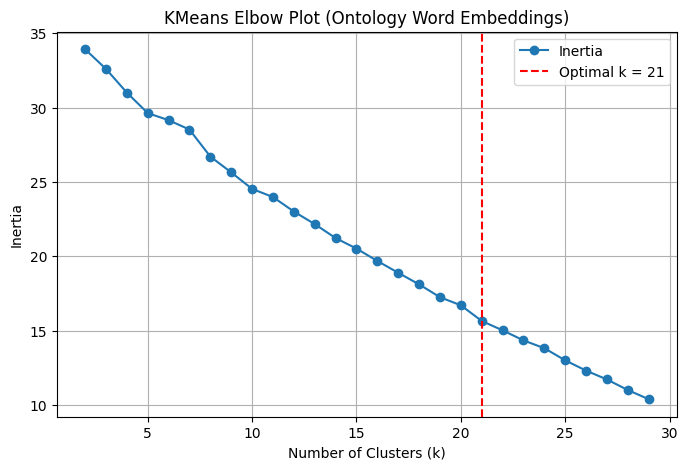

Optimal k selected by elbow method: 21


In [29]:
X = df.drop(columns=['word', 'category']).values
k_range = range(2, 30)

inertias = kmeans_elbow(X, k_range)
optimal_k = plot_elbow_with_knee(k_range, inertias, title="KMeans Elbow Plot (Ontology Word Embeddings)")
print(f"Optimal k selected by elbow method: {optimal_k}")

In [48]:
kmeans = KMeans(n_clusters=21, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

### 4. Visualization

In [49]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
centroids_2d = pca.transform(kmeans.cluster_centers_)

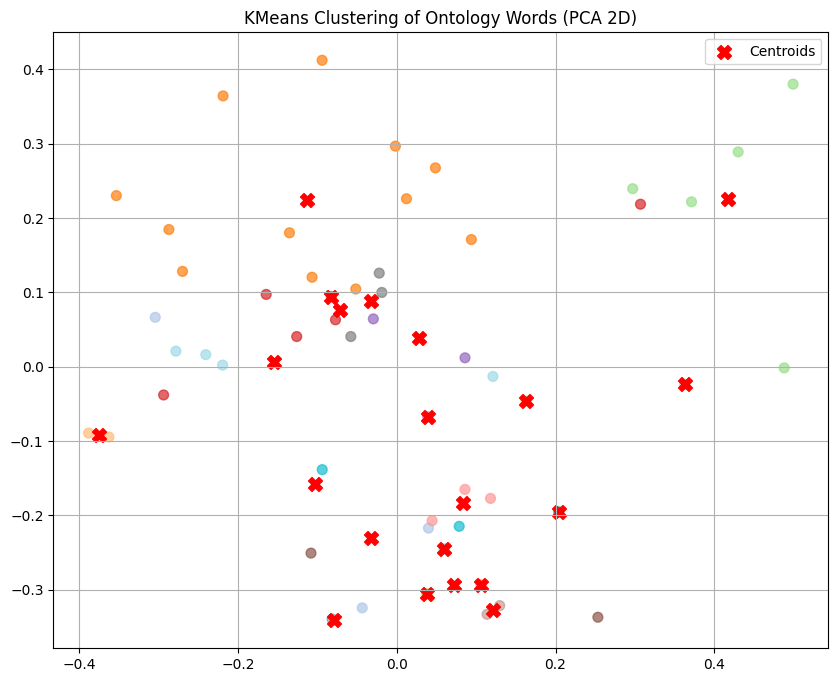

In [50]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', s=50, alpha=0.7)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', s=100, marker='X', label='Centroids')
plt.title("KMeans Clustering of Ontology Words (PCA 2D)")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# X_pca: shape (n_samples, 2), labels: shape (n_samples,), centroids_2d: shape (n_clusters, 2)
def visualize_PCA(X_pca,centroids_2d):

  plt.figure(figsize=(10, 8))


  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', s=50, alpha=0.7)
  plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', s=120, marker='X', label='Centroids')

  for idx, (x, y) in enumerate(centroids_2d):
      plt.text(x + 0.01, y + 0.01, f'C{idx}', fontsize=9, weight='bold', color='red')

  plt.title("KMeans Clustering of Ontology Words (PCA 2D)")
  plt.xlabel("PCA 1")
  plt.ylabel("PCA 2")
  plt.legend()
  plt.grid(True)
  plt.show()

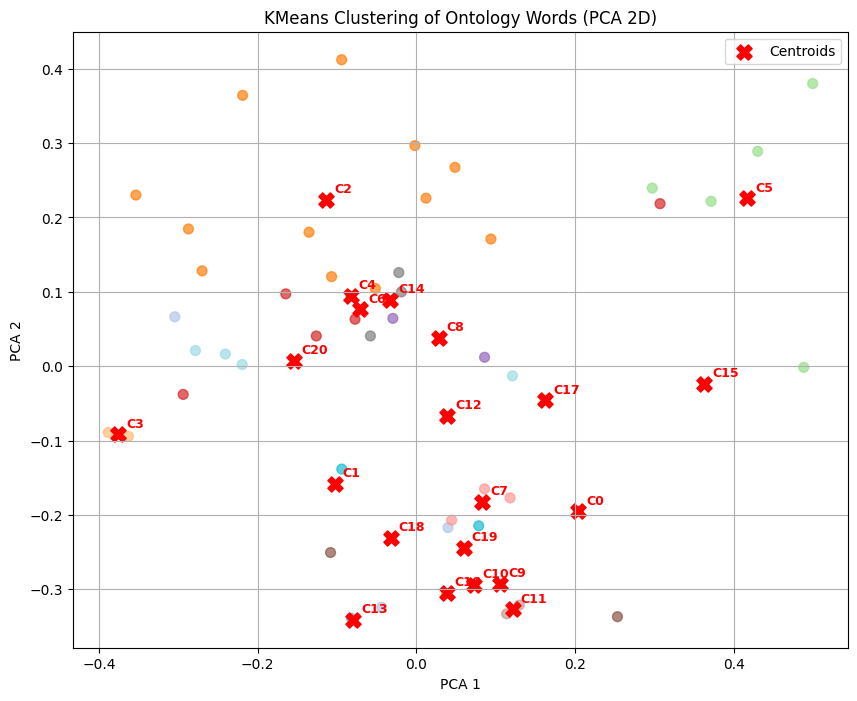

In [51]:
visualize_PCA(X_pca, centroids_2d)

In [36]:
##
n = len(categories)
kmeans_n = KMeans(n_clusters=n, random_state=42, n_init='auto')
labels_n = kmeans_n.fit_predict(X)

In [40]:
pca = PCA(n_components=2)
X_pca_n = pca.fit_transform(X)
centroids_2d_n = pca.transform(kmeans_n.cluster_centers_)

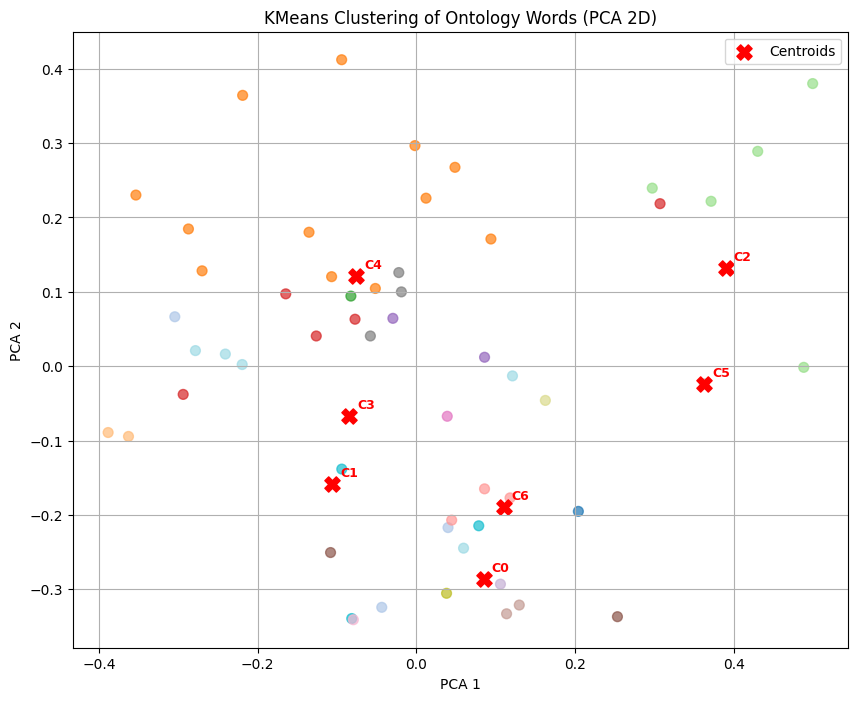

In [41]:
visualize_PCA(X_pca_n, centroids_2d_n)

In [45]:
print(len(kmeans.labels_))

55


In [56]:
print(df.shape)
print(X.shape)
print(words[:5])
print(df['word'].tolist()[:5] == words[:5])

(55, 386)
(55, 384)
['bat', 'fruit bat', 'vampire bat', 'flying fox', 'pipistrelle']
False


In [58]:
cluster_to_words = defaultdict(list)

for label, word in zip(kmeans.labels_, df['word']):
    cluster_to_words[label].append(word)

for cluster_id, word_list in sorted(cluster_to_words.items()):
    print(f"Cluster {cluster_id} ({len(word_list)} words): {word_list}")

Cluster 0 (1 words): ['dugong']
Cluster 1 (3 words): ['tarsier', 'cat', 'pipistrelle']
Cluster 2 (12 words): ['mammal', 'animal', 'vertebrate', 'organism', 'species', 'creature', 'dog', 'domestic dog', 'wild dog', 'cheetah', 'hamster', 'guinea pig']
Cluster 3 (2 words): ['fox', 'flying fox']
Cluster 4 (1 words): ['tiger']
Cluster 5 (5 words): ['primate', 'monkey', 'chimpanzee', 'gorilla', 'gibbon']
Cluster 6 (5 words): ['lemur', 'sea lion', 'lion', 'leopard', 'jaguar']
Cluster 7 (3 words): ['bat', 'fruit bat', 'vampire bat']
Cluster 8 (2 words): ['whale', 'dolphin']
Cluster 9 (1 words): ['gerbil']
Cluster 10 (2 words): ['baboon', 'bobcat']
Cluster 11 (2 words): ['porpoise', 'porcupine']
Cluster 12 (1 words): ['living thing']
Cluster 13 (1 words): ['jackal']
Cluster 14 (3 words): ['mouse', 'rat', 'squirrel']
Cluster 15 (1 words): ['orangutan']
Cluster 16 (1 words): ['seal']
Cluster 17 (1 words): ['manatee']
Cluster 18 (3 words): ['narwhal', 'beluga', 'cougar']
Cluster 19 (1 words): ['di

In [59]:
cluster_to_words_n = defaultdict(list)

for label, word in zip(kmeans_n.labels_, df['word']):
    cluster_to_words_n[label].append(word)

for cluster_id, word_list in sorted(cluster_to_words_n.items()):
    print(f"Cluster {cluster_id} ({len(word_list)} words): {word_list}")

Cluster 0 (3 words): ['porpoise', 'dugong', 'jackal']
Cluster 1 (6 words): ['tarsier', 'dingo', 'cat', 'lynx', 'bobcat', 'pipistrelle']
Cluster 2 (6 words): ['primate', 'monkey', 'chimpanzee', 'gorilla', 'baboon', 'gibbon']
Cluster 3 (13 words): ['lemur', 'sea lion', 'narwhal', 'fox', 'lion', 'tiger', 'leopard', 'jaguar', 'cougar', 'gerbil', 'bat', 'vampire bat', 'flying fox']
Cluster 4 (22 words): ['mammal', 'animal', 'vertebrate', 'organism', 'living thing', 'species', 'creature', 'whale', 'dolphin', 'seal', 'dog', 'wolf', 'coyote', 'domestic dog', 'wild dog', 'cheetah', 'mouse', 'rat', 'squirrel', 'beaver', 'hamster', 'guinea pig']
Cluster 5 (1 words): ['orangutan']
Cluster 6 (4 words): ['manatee', 'beluga', 'porcupine', 'fruit bat']


### 5. Cosine Similarity Analysis
1. between center and representative word
  - set the closest word in each cluster as representative word
2. between center and words in each cluster

- Between Center and Representative word

In [76]:
# 1. between center and representative word

centers = kmeans.cluster_centers_
word_embeddings = df.drop(columns=["word", "category"]).values
word_list = df["word"].values

word_to_embedding = {word: emb for word, emb in zip(word_list, word_embeddings)}

cluster_analysis = {}

for cluster_id, word_list in cluster_to_words.items():
    center = centers[cluster_id]
    similarities = []

    for word in word_list:
        sim = cosine_similarity([center], [word_to_embedding[word]])[0][0]
        similarities.append((word, sim))

    # set representative word
    representative_word, max_sim = max(similarities, key=lambda x: x[1])

    cluster_analysis[cluster_id] = {
        "representative": representative_word,
        "similarity": max_sim,
        "all_similarities": similarities,
        "mean_similarity": np.mean([s for _, s in similarities]),
        "std_similarity": np.std([s for _, s in similarities])
    }

In [78]:
# for cid, info in cluster_analysis.items():
#     print(f"Cluster {cid}: Representative = '{info['representative']}' (sim = {info['similarity']:.4f})")
#     print(f"  Mean CosSim = {info['mean_similarity']:.4f}, Std = {info['std_similarity']:.4f}")
#     print()


In [77]:
cluster_df = pd.DataFrame([
    {
        "Cluster ID": cid,
        "Representative Word": data["representative"],
        "Representative CosSim": data["similarity"],
        "Mean CosSim": data["mean_similarity"],
        "Std CosSim": data["std_similarity"],
    }
    for cid, data in cluster_analysis.items()
])

cluster_df = cluster_df.sort_values(by="Cluster ID").reset_index(drop=True)

In [64]:
print(cluster_df)

    Cluster ID Representative Word  Representative CosSim  Mean CosSim  \
0            0              dugong               1.000000     1.000000   
1            1         pipistrelle               0.783792     0.770652   
2            2              animal               0.907103     0.737545   
3            3          flying fox               0.937633     0.937633   
4            4               tiger               1.000000     1.000000   
5            5             primate               0.892401     0.828928   
6            6                lion               0.896367     0.797291   
7            7                 bat               0.932654     0.897885   
8            8               whale               0.918110     0.918110   
9            9              gerbil               1.000000     1.000000   
10          10              baboon               0.880300     0.880300   
11          11            porpoise               0.910782     0.910782   
12          12        living thing    

- Between Center and Words in Cluster

In [79]:
cluster_similarities = defaultdict(list)

for idx, row in df.iterrows():
    word_vector = X[idx]
    cluster_id = kmeans.labels_[idx]
    center_vector = kmeans.cluster_centers_[cluster_id]

    sim = cosine_similarity([center_vector], [word_vector])[0][0]
    cluster_similarities[cluster_id].append(sim)

In [80]:
similarity_stats = []
for cluster_id, sims in cluster_similarities.items():
    similarity_stats.append({
        "Cluster ID": cluster_id,
        "Mean CosSim": np.mean(sims),
        "Std CosSim": np.std(sims),
        "Num Words": len(sims)
    })

In [81]:
cos_sim_df = pd.DataFrame(similarity_stats).sort_values(by="Cluster ID").reset_index(drop=True)

In [68]:
print(cos_sim_df)

    Cluster ID  Mean CosSim    Std CosSim  Num Words
0            0     1.000000  0.000000e+00          1
1            1     0.770652  9.611419e-03          3
2            2     0.737545  7.804618e-02         12
3            3     0.937633  4.214685e-08          2
4            4     1.000000  0.000000e+00          1
5            5     0.828928  5.260260e-02          5
6            6     0.797291  7.896301e-02          5
7            7     0.897885  2.713854e-02          3
8            8     0.918110  4.214685e-08          2
9            9     1.000000  0.000000e+00          1
10          10     0.880300  4.214685e-08          2
11          11     0.910782  0.000000e+00          2
12          12     1.000000  0.000000e+00          1
13          13     1.000000  0.000000e+00          1
14          14     0.834185  3.471287e-02          3
15          15     1.000000  0.000000e+00          1
16          16     1.000000  0.000000e+00          1
17          17     1.000000  0.000000e+00     

### 6. Hierarchy Alignment Analysis

In [92]:
ontology_hierarchy = {
    "animal": {
        "mammal": {
            "primates": primates,
            "aquatic_mammals": aquatic_mammals,
            "canines": canines,
            "felines": felines,
            "rodents": rodents,
            "bats": bats,
        }
    }
}

In [87]:
word_to_cluster = {}
for cluster_id, words in cluster_to_words.items():
    for word in words:
        word_to_cluster[word] = cluster_id

print(word_to_cluster)

{'mammal': np.int32(2), 'animal': np.int32(2), 'vertebrate': np.int32(2), 'organism': np.int32(2), 'species': np.int32(2), 'creature': np.int32(2), 'dog': np.int32(2), 'domestic dog': np.int32(2), 'wild dog': np.int32(2), 'cheetah': np.int32(2), 'hamster': np.int32(2), 'guinea pig': np.int32(2), 'living thing': np.int32(12), 'primate': np.int32(5), 'monkey': np.int32(5), 'chimpanzee': np.int32(5), 'gorilla': np.int32(5), 'gibbon': np.int32(5), 'baboon': np.int32(10), 'bobcat': np.int32(10), 'lemur': np.int32(6), 'sea lion': np.int32(6), 'lion': np.int32(6), 'leopard': np.int32(6), 'jaguar': np.int32(6), 'orangutan': np.int32(15), 'tarsier': np.int32(1), 'cat': np.int32(1), 'pipistrelle': np.int32(1), 'whale': np.int32(8), 'dolphin': np.int32(8), 'porpoise': np.int32(11), 'porcupine': np.int32(11), 'manatee': np.int32(17), 'dugong': np.int32(0), 'seal': np.int32(16), 'narwhal': np.int32(18), 'beluga': np.int32(18), 'cougar': np.int32(18), 'wolf': np.int32(20), 'coyote': np.int32(20), 'l

In [88]:
category_to_cluster_ids = {}
for category, word_list in category_indices.items():
    cluster_ids = set()
    for word in word_list:
        if word in word_to_cluster:
            cluster_ids.add(word_to_cluster[word])
    if cluster_ids:
        category_to_cluster_ids[category] = list(cluster_ids)

In [89]:
print(category_to_cluster_ids)

{'mammals': [np.int32(2), np.int32(12)], 'primates': [np.int32(1), np.int32(5), np.int32(6), np.int32(10), np.int32(15)], 'aquatic_mammals': [np.int32(0), np.int32(6), np.int32(8), np.int32(11), np.int32(16), np.int32(17), np.int32(18)], 'canines': [np.int32(2), np.int32(3), np.int32(13), np.int32(19), np.int32(20)], 'felines': [np.int32(1), np.int32(2), np.int32(4), np.int32(6), np.int32(10), np.int32(18), np.int32(20)], 'rodents': [np.int32(2), np.int32(9), np.int32(11), np.int32(14), np.int32(20)], 'bats': [np.int32(1), np.int32(3), np.int32(7)]}


In [90]:
cluster_centers = {cid: center for cid, center in enumerate(kmeans.cluster_centers_)}
category_center_vectors = {}

for category, cluster_ids in category_to_cluster_ids.items():
    vectors = [cluster_centers[cid] for cid in cluster_ids]
    category_center_vectors[category] = np.mean(vectors, axis=0)

In [94]:
alignment_stats = []

for parent, children in ontology_hierarchy["animal"].items():  # parent: 'mammal'
    parent_vector = word_to_embedding.get(parent)
    for child_cat in children.keys():
        child_vector = category_center_vectors.get(child_cat)
        if parent_vector is not None and child_vector is not None:
            sim = cosine_similarity([parent_vector], [child_vector])[0][0]
            alignment_stats.append({
                "Parent Category": parent,
                "Child Category": child_cat,
                "Cosine Similarity": sim
            })

In [95]:
print(alignment_stats)

[{'Parent Category': 'mammal', 'Child Category': 'primates', 'Cosine Similarity': np.float32(0.59257793)}, {'Parent Category': 'mammal', 'Child Category': 'aquatic_mammals', 'Cosine Similarity': np.float32(0.57803655)}, {'Parent Category': 'mammal', 'Child Category': 'canines', 'Cosine Similarity': np.float32(0.61427116)}, {'Parent Category': 'mammal', 'Child Category': 'felines', 'Cosine Similarity': np.float32(0.6680566)}, {'Parent Category': 'mammal', 'Child Category': 'rodents', 'Cosine Similarity': np.float32(0.69492507)}, {'Parent Category': 'mammal', 'Child Category': 'bats', 'Cosine Similarity': np.float32(0.5825181)}]


In [96]:
alignment_df = pd.DataFrame(alignment_stats).sort_values(by="Cosine Similarity", ascending=False).reset_index(drop=True)
print(alignment_df)

  Parent Category   Child Category  Cosine Similarity
0          mammal          rodents           0.694925
1          mammal          felines           0.668057
2          mammal          canines           0.614271
3          mammal         primates           0.592578
4          mammal             bats           0.582518
5          mammal  aquatic_mammals           0.578037


- animal
  - mammals
    - primates
    - aquatic_mammals
    - canines
    - felines
    - rodents
    - bats

In [97]:
category_names = list(category_center_vectors.keys())
category_vectors = np.array([category_center_vectors[cat] for cat in category_names])

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(category_vectors)

category_to_pca = {name: coord for name, coord in zip(category_names, pca_coords)}

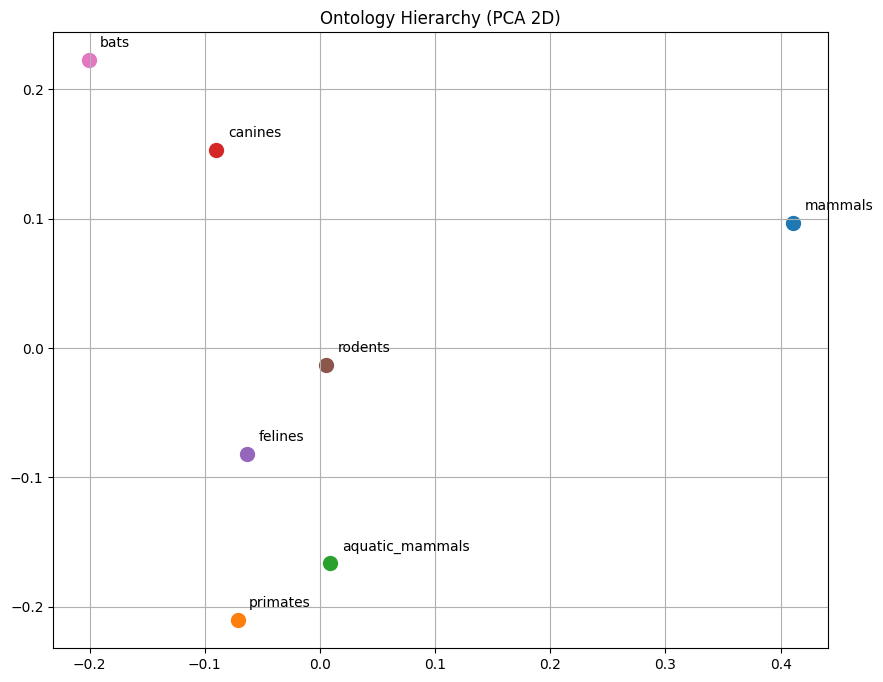

In [98]:
plt.figure(figsize=(10, 8))

for category, coord in category_to_pca.items():
    plt.scatter(*coord, s=100)
    plt.text(coord[0] + 0.01, coord[1] + 0.01, category, fontsize=10)

for parent, children in ontology_hierarchy["animal"].items():  # parent: 'mammal'
    parent_coord = category_to_pca.get(parent)
    for child_cat in children.keys():
        child_coord = category_to_pca.get(child_cat)
        if parent_coord is not None and child_coord is not None:
            plt.arrow(parent_coord[0], parent_coord[1],
                      child_coord[0] - parent_coord[0],
                      child_coord[1] - parent_coord[1],
                      head_width=0.01, length_includes_head=True, color='gray')

plt.title("Ontology Hierarchy (PCA 2D)")
plt.grid(True)
plt.show()